In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

for path in sorted((ROOT / "news_data").glob("*.csv")):
    cols = pd.read_csv(path, nrows=0).columns.tolist()
    print(f"\n{path.name}")
    print(cols)


economic_times_headlines_2022.csv
['Archive', 'Date', 'Headline', 'Headline link']

economic_times_headlines_2023.csv
['Archive', 'Date', 'Headline', 'Headline link']

economic_times_headlines_2024.csv
['Archive', 'Date', 'Headline', 'Headline link']

economic_times_headlines_2025.csv
['Archive', 'Date', 'Headline', 'Headline link']

filtered_market_news_updated.csv
['title', 'link', 'date', 'source', 'fetched_at']

IndianFinancialNews.csv
['Unnamed: 0', 'Date', 'Title', 'Description']

news_gap_2025_06_12_to_2026_04_15.csv
['Archive', 'Date', 'Headline', 'Description', 'Headline link', 'Source', 'Query']

News_sentiment_Jan2017_to_Apr2021.csv
['Date', 'Title', 'URL', 'sentiment', 'confidence', 'Unnamed: 5']

news_unified.csv
['source_file', 'source', 'date', 'title', 'description', 'url', 'archive', 'sentiment', 'confidence']


In [2]:
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

NEWS_DIR = ROOT / "news_data"
COMMON_SCHEMA = ["date", "title", "description", "url", "source_file"]

def parse_mixed_date(series):
    s = series.astype("string").str.strip()
    parsed = pd.Series(pd.NaT, index=series.index, dtype="datetime64[ns]")

    formats = [
        "%d-%m-%Y",          # economic_times_*.csv
        "%B %d, %Y, %A",     # IndianFinancialNews.csv
        "%d/%m/%y",          # News_sentiment_Jan2017_to_Apr2021.csv
    ]

    for fmt in formats:
        mask = parsed.isna()
        parsed.loc[mask] = pd.to_datetime(s.loc[mask], format=fmt, errors="coerce")

    mask = parsed.isna()
    parsed.loc[mask] = pd.to_datetime(s.loc[mask], errors="coerce", dayfirst=True)

    return parsed.dt.strftime("%Y-%m-%d")

def first_existing(df, cols):
    for col in cols:
        if col in df.columns:
            return df[col]
    return pd.Series(pd.NA, index=df.index, dtype="object")

all_news = []

for path in sorted(NEWS_DIR.glob("*.csv")):
    if path.name == "news_unified.csv":
        continue

    df = pd.read_csv(path)

    # remove unnamed / empty columns
    df = df.loc[:, [
        c for c in df.columns
        if str(c).strip() and not str(c).lower().startswith("unnamed:")
    ]]

    out = pd.DataFrame(index=df.index)
    out["date"] = parse_mixed_date(first_existing(df, ["Date"]))
    out["title"] = first_existing(df, ["Headline", "Title", "Description"]).astype("string").str.strip()
    out["description"] = first_existing(df, ["Description"]).astype("string").str.strip()
    out["url"] = first_existing(df, ["Headline link", "URL"]).astype("string").str.strip()
    out["source_file"] = path.name

    # if description missing it  use title
    out["description"] = out["description"].fillna(out["title"])

    # remove rows where all main fields are missing
    out = out.dropna(subset=["date", "title", "description", "url"], how="all")

    all_news.append(out[COMMON_SCHEMA])
    
news_df = pd.concat(all_news, ignore_index=True)
news_df = news_df.sort_values(["date", "source_file", "title"], na_position="last").reset_index(drop=True)

print("Shape:", news_df.shape)
print(news_df["source_file"].value_counts())
display(news_df.sample(10))




Shape: (607181, 5)
source_file
News_sentiment_Jan2017_to_Apr2021.csv    200500
economic_times_headlines_2023.csv        117469
economic_times_headlines_2022.csv        108599
economic_times_headlines_2024.csv         93244
IndianFinancialNews.csv                   50000
economic_times_headlines_2025.csv         30689
news_gap_2025_06_12_to_2026_04_15.csv      6680
Name: count, dtype: int64


,date,title,description,url,source_file
100911,2018-02-09,"Sensex down 400 points to 33 , 997 , Nifty at ...","Sensex down 400 points to 33 , 997 , Nifty at ...",http://www.businesstoday.in/markets/stocks/sen...,News_sentiment_Jan2017_to_Apr2021.csv
546239,2024-09-02,Tourism’s contribution to economy will exceed ...,Tourism’s contribution to economy will exceed ...,https://economictimes.indiatimes.com/industry/...,economic_times_headlines_2024.csv
439465,2023-09-11,"As ‘Jailer’ strikes gold at box-office, produc...","As ‘Jailer’ strikes gold at box-office, produc...",https://economictimes.indiatimes.com/magazines...,economic_times_headlines_2023.csv
519194,2024-05-12,M3M to lease 1.5 million sq ft of commercial s...,M3M to lease 1.5 million sq ft of commercial s...,https://economictimes.indiatimes.com/industry/...,economic_times_headlines_2024.csv
71892,2017-07-28,Coromandel International Q1 net jumps 90 % on ...,Coromandel International Q1 net jumps 90 % on ...,http://economictimes.indiatimes.com/markets/st...,News_sentiment_Jan2017_to_Apr2021.csv
381805,2023-03-16,4 largecaps that beat volatility and negative ...,4 largecaps that beat volatility and negative ...,https://economictimes.indiatimes.com/markets/s...,economic_times_headlines_2023.csv
180898,2019-09-28,"Expect Nifty to return 20 % in next one year ,...","Expect Nifty to return 20 % in next one year ,...",https://www.moneycontrol.com/news/business/mar...,News_sentiment_Jan2017_to_Apr2021.csv
574937,2025-01-14,"Rupee weakening: Limited impact on inflation, ...","Rupee weakening: Limited impact on inflation, ...",https://economictimes.indiatimes.com/news/econ...,economic_times_headlines_2025.csv
295778,2022-06-16,Jio adds 16.8 lakh mobile subscribers in April...,Jio adds 16.8 lakh mobile subscribers in April...,https://economictimes.indiatimes.com/industry/...,economic_times_headlines_2022.csv
378998,2023-03-06,Yes Bank lock-in period ends next week; know w...,Yes Bank lock-in period ends next week; know w...,https://economictimes.indiatimes.com/markets/s...,economic_times_headlines_2023.csv


In [3]:
news_df = pd.concat(all_news, ignore_index=True)
news_df = news_df.sort_values(["date", "source_file", "title"], na_position="last").reset_index(drop=True)

print(news_df.shape)
display(news_df.sample(20))

(607181, 5)


,date,title,description,url,source_file
303475,2022-07-13,5 best emergency loans online for immediate em...,5 best emergency loans online for immediate em...,https://economictimes.indiatimes.com/wealth/bo...,economic_times_headlines_2022.csv
533534,2024-07-11,Three major defence testing facilities to be l...,Three major defence testing facilities to be l...,https://economictimes.indiatimes.com/news/defe...,economic_times_headlines_2024.csv
320991,2022-09-07,What titles will Netflix remove this September...,What titles will Netflix remove this September...,https://economictimes.indiatimes.com/magazines...,economic_times_headlines_2022.csv
102048,2018-02-16,UltraTech : Binani buy doesnt defy CCI Rules :...,UltraTech : Binani buy doesnt defy CCI Rules :...,https://economictimes.indiatimes.com/industry/...,News_sentiment_Jan2017_to_Apr2021.csv
408636,2023-06-13,EY Global Delivery Services India renews offic...,EY Global Delivery Services India renews offic...,https://economictimes.indiatimes.com/industry/...,economic_times_headlines_2023.csv
313358,2022-08-13,Over Rs 6 crore worth of land seized in case a...,Over Rs 6 crore worth of land seized in case a...,https://economictimes.indiatimes.com/news/poli...,economic_times_headlines_2022.csv
12481,2007-08-24,Banks to start new pension plan,In their first step towards introducing a pens...,<NA>,IndianFinancialNews.csv
297238,2022-06-21,CBI apprehends joint drugs controller taking R...,CBI apprehends joint drugs controller taking R...,https://economictimes.indiatimes.com/news/indi...,economic_times_headlines_2022.csv
494249,2024-02-21,Union Bank of India share price jumps 7% on Rs...,Union Bank of India share price jumps 7% on Rs...,https://economictimes.indiatimes.com/markets/s...,economic_times_headlines_2024.csv
50628,2017-02-28,"Employee strike paralyses banking operations ,...","Employee strike paralyses banking operations ,...",http://www.financialexpress.com/india-news/emp...,News_sentiment_Jan2017_to_Apr2021.csv


In [4]:
def filter_news(df: pd.DataFrame) -> pd.DataFrame:
    # Combine title + description once as a vectorized Series
    text_series = (
        df["title"].fillna("") + " " + df["description"].fillna("")
    ).str.lower()

    all_keywords = {
        "stock_specific":   [n for names in COMPANY_NAMES.values() for n in names]
                            + [t.lower() for t in TICKERS],
        "macro_government": MACRO_KEYWORDS,
        "geopolitical":     GEO_KEYWORDS,
        "research_rd":      RESEARCH_KEYWORDS,
        **{f"sector_{k}": v for k, v in SECTOR_KEYWORDS.items()},
    }

    # Build one boolean mask per category using str.contains
    masks = {}
    for cat, kws in all_keywords.items():
        pattern = "|".join(re.escape(k) for k in kws)
        masks[cat] = text_series.str.contains(pattern, regex=True, na=False)

    # Combined mask — keep row if ANY category matched
    combined = pd.concat(masks.values(), axis=1).any(axis=1)
    filtered = df[combined].copy()

    # Add helper columns
    filtered["categories"] = [
        "|".join(cat for cat, mask in masks.items() if mask[i])
        for i in filtered.index
    ]
    filtered["matched_keywords"] = filtered.index.map(
        lambda i: "|".join(
            kw for cat, kws in all_keywords.items()
            for kw in kws
            if mask[i] and kw in text_series[i]
            for mask in [masks[cat]]
        )
    )
    filtered["relevance_score"] = filtered["categories"].str.count(r"\|") + 1

    return filtered.drop_duplicates(subset=["title"]) \
                   .sort_values("relevance_score", ascending=False) \
                   .reset_index(drop=True)

## filtering news 

In [5]:
import re
import yaml

with open(r"C:\Users\laves\backup\nifty-50-50\config.yaml") as f:
    cfg = yaml.safe_load(f)

TICKERS = cfg["tickers"]
TICKER_MAP = cfg.get("ticker_map", {})

#### companies name 

In [6]:
COMPANY_NAMES = {
    "ADANIENT":    ["adani enterprises", "adani group"],
    "ADANIPORTS":  ["adani ports", "adani port"],
    "APOLLOHOSP":  ["apollo hospital", "apollo health"],
    "ASIANPAINT":  ["asian paints", "asian paint"],
    "AXISBANK":    ["axis bank"],
    "BAJAJ-AUTO":  ["bajaj auto"],
    "BAJAJFINSV":  ["bajaj finserv"],
    "BAJFINANCE":  ["bajaj finance"],
    "BHARTIARTL":  ["bharti airtel", "airtel"],
    "BPCL":        ["bharat petroleum", "bpcl"],
    "BRITANNIA":   ["britannia"],
    "CIPLA":       ["cipla"],
    "COALINDIA":   ["coal india"],
    "DIVISLAB":    ["divi's lab", "divis lab", "divi laboratories"],
    "DRREDDY":     ["dr. reddy", "dr reddy", "drreddys"],
    "EICHERMOT":   ["eicher motors", "royal enfield"],
    "GRASIM":      ["grasim"],
    "HCLTECH":     ["hcl tech", "hcltech", "hcl technologies"],
    "HDFCBANK":    ["hdfc bank"],
    "HDFCLIFE":    ["hdfc life"],
    "HEROMOTOCO":  ["hero motocorp", "hero moto"],
    "HINDALCO":    ["hindalco"],
    "HINDUNILVR":  ["hindustan unilever", "hul"],
    "ICICIBANK":   ["icici bank"],
    "INDUSINDBK":  ["indusind bank"],
    "INFY":        ["infosys"],
    "ITC":         ["itc ltd", "itc limited"],
    "JSWSTEEL":    ["jsw steel"],
    "KOTAKBANK":   ["kotak bank", "kotak mahindra bank"],
    "LT":          ["larsen & toubro", "l&t"],
    "LTIM":        ["ltimindtree", "lti mindtree"],
    "MARUTI":      ["maruti suzuki", "maruti"],
    "MM":          ["mahindra & mahindra", "m&m"],
    "NESTLEIND":   ["nestle india", "nestle"],
    "NTPC":        ["ntpc"],
    "ONGC":        ["ongc", "oil and natural gas"],
    "POWERGRID":   ["power grid", "powergrid"],
    "RELIANCE":    ["reliance industries", "reliance jio", "jio"],
    "SBILIFE":     ["sbi life"],
    "SBIN":        ["state bank of india", "sbi"],
    "SUNPHARMA":   ["sun pharma", "sun pharmaceutical"],
    "TATACONSUM":  ["tata consumer", "tata tea"],
    "TATAMOTORS":  ["tata motors", "jaguar land rover", "jlr"],
    "TATASTEEL":   ["tata steel"],
    "TCS":         ["tata consultancy", "tcs"],
    "TECHM":       ["tech mahindra"],
    "TITAN":       ["titan company", "tanishq"],
    "ULTRACEMCO":  ["ultratech cement"],
    "UPL":         ["upl limited", "upl ltd"],
    "WIPRO":       ["wipro"],
}

#### sector related keywords 

In [7]:
SECTOR_KEYWORDS = {
    "banking_finance": [
        "rbi", "repo rate", "monetary policy", "npa", "credit growth",
        "interest rate", "banking sector", "nbfc", "emi", "loan growth",
        "liquidity", "crr", "slr", "basel", "fdi in banking",
        "bad loans", "bank fraud", "bank merger", "bank license",
        "microfinance", "priority sector lending",
    ],
    "it_tech": [
        "it sector", "software exports", "digital india", "cloud computing",
        "ai deal", "tech layoffs", "visa h1b", "rupee hedging it",
        "tech hiring", "outsourcing", "software services",
        "data centre", "data center", "cybersecurity", "saas",
        "it spending", "digital transformation",
    ],
    "pharma_health": [
        "pharma", "drug approval", "usfda", "fda approval", "generic drug",
        "api shortage", "healthcare", "clinical trial", "biosimilar",
        "drug recall", "medical device", "dcgi", "drug launch",
        "ayushman bharat", "health insurance", "hospital chain",
    ],
    "auto": [
        "auto sales", "ev policy", "electric vehicle", "automobile", "scrappage",
        "vehicle registration", "two-wheeler", "passenger vehicle",
        "commercial vehicle", "auto sector", "vehicle financing",
        "charging infrastructure", "ev subsidy", "fame scheme",
    ],
    "energy_oil": [
        "crude oil", "brent", "opec", "petroleum price", "natural gas",
        "fuel price", "petrol price", "diesel price", "energy transition",
        "renewable energy", "solar capacity", "wind energy",
        "power tariff", "electricity demand", "power shortage",
        "coal shortage", "gas pipeline",
    ],
    "metals_mining": [
        "steel price", "iron ore", "aluminium", "copper price",
        "metal sector", "mining", "coking coal", "base metal",
        "zinc", "nickel", "lithium", "rare earth",
        "mining license", "mining auction",
    ],
    "fmcg_consumer": [
        "fmcg", "consumer goods", "rural demand", "urban consumption",
        "inflation impact consumer", "volume growth fmcg",
        "consumer sentiment", "retail sales", "festive demand",
        "e-commerce", "quick commerce",
    ],
    "cement_infra": [
        "cement", "infrastructure", "roads", "highways", "construction",
        "real estate", "housing demand", "capital expenditure",
        "smart city", "metro rail", "port development", "airport",
        "bridge project", "dam project",
    ],
    "telecom": [
        "5g rollout", "spectrum", "telecom sector", "arpu", "jio",
        "airtel", "mobile subscriber", "broadband",
        "fiber optic", "satellite internet", "starlink india",
        "telecom tariff", "trai",
    ],
}

#### macro and geopolitical key words

In [8]:
MACRO_KEYWORDS = [
    "union budget", "fiscal deficit", "capital expenditure", "capex",
    "government spending", "infrastructure investment", "pli scheme",
    "production linked incentive", "make in india", "atmanirbhar",
    "rbi policy", "repo rate", "monetary policy committee", "mpc",
    "inflation", "cpi", "wpi", "fii", "fpi", "dii", "foreign investment",
    "sebi", "ipo", "qip", "block deal", "nifty 50", "sensex",
    "stock market rally", "market crash", "bull run", "bear market",
    "index rebalancing", "nifty rebalance",
    "india gdp", "trade deficit", "export growth", "import",
    "current account", "forex reserve", "rupee", "dollar",
    "gst collection", "tax revenue", "disinvestment", "privatisation",
    "subsidy", "msme", "startup india", "direct tax", "indirect tax",
]

GEO_KEYWORDS = [
    "russia ukraine", "ukraine war", "middle east conflict", "israel hamas",
    "iran sanctions", "north korea", "taiwan strait", "south china sea",
    "us china trade", "tariff", "trade war", "trade sanction",
    "export ban", "import restriction", "embargo",
    "suez canal", "red sea shipping", "strait of hormuz",
    "oil supply disruption", "gas supply europe",
    "fed rate", "us fed", "federal reserve", "recession fear",
    "global slowdown", "imf forecast", "world bank forecast",
    "demonetization", "lockdown", "pandemic", "corona", "covid",
    "geopolitical tension", "military conflict", "war",
    "natural disaster", "earthquake", "flood impact economy",
    "election result india", "political uncertainty",
]

#### events keyword 

In [9]:
RESEARCH_KEYWORDS = [
    "patent filed", "patent granted", "research breakthrough",
    "clinical study", "clinical trial result", "fda approval",
    "new drug", "drug launch", "product launch", "new technology",
    "ai launch", "generative ai", "large language model",
    "semiconductor", "chip shortage", "chip manufacturing",
    "ev battery", "solid state battery", "green hydrogen",
    "carbon capture", "solar efficiency", "fusion energy",
    "biotech discovery", "genome", "cancer therapy",
    "collaboration agreement", "joint venture", "technology transfer",
]

EARNINGS_KEYWORDS = [
    "quarterly results", "q1 results", "q2 results", "q3 results", "q4 results",
    "net profit", "net loss", "ebitda", "revenue growth", "pat",
    "earnings beat", "earnings miss", "profit rises", "profit falls",
    "revenue rises", "revenue falls", "margin expansion", "margin pressure",
    "annual results", "full year results", "operating profit",
    "gross margin", "topline growth", "bottomline",
    "dividend declared", "dividend announced", "bonus share",
    "stock split", "rights issue", "buyback",
]

ORDER_KEYWORDS = [
    "order win", "order wins", "wins order", "bagged order",
    "bags order", "secures order", "contract awarded", "contract win",
    "l1 bidder", "lowest bidder", "project awarded",
    "deal signed", "mou signed", "agreement signed",
    "merger", "acquisition", "takeover", "stake sale",
    "strategic partnership", "joint venture",
    "export order", "defence order", "government contract",
    "tender win", "bid win", "awarded contract",
]

MGMT_KEYWORDS = [
    "ceo resigns", "ceo appointed", "md resigns", "cfo resigns",
    "management change", "board reshuffle", "chairman steps down",
    "new ceo", "new md", "promoter stake", "promoter selling",
    "insider buying", "insider selling", "pledging shares",
    "corporate governance", "whistleblower", "fraud allegation",
    "accounting irregularity", "audit concern",
]

RATING_REGULATORY_KEYWORDS = [
    "rating upgrade", "rating downgrade", "credit rating",
    "moody's", "s&p rating", "fitch", "icra", "crisil", "care ratings",
    "credit watch", "outlook revised", "rating affirmed",
    "sebi notice", "sebi penalty", "sebi order", "rbi penalty",
    "nclt", "insolvency", "ird", "ed raid", "enforcement directorate",
    "income tax raid", "cbi investigation", "regulatory action",
    "show cause notice", "ban lifted", "suspension lifted",
]

In [10]:
NEGATION_PATTERNS = [
    r"\bno\s+\w+\s+(order|deal|contract|profit|growth)\b",
    r"\b(denies|deny|denied)\s+(order|deal|contract|allegations)\b",
    r"\b(rules out|ruled out)\b",
    r"\b(no change in|unchanged)\s+(repo|rate|policy)\b",
    r"\b(not expecting|does not expect)\b",
    r"\bcancelled\s+(order|contract|deal)\b",
    r"\b(lost|loses)\s+(order|contract|bid|deal)\b",
]

CATEGORY_WEIGHTS = {
    "macro_government":              3,
    "geopolitical":                  3,
    "earnings_results":              3,
    "order_wins_deals":              3,
    "rating_regulatory":             2,
    "management_corporate":          2,
    "stock_specific":                2,
    "research_rd":                   2,
    "sector_banking_finance":        2,
    "sector_it_tech":                2,
    "sector_pharma_health":          2,
    "sector_auto":                   1,
    "sector_energy_oil":             2,
    "sector_metals_mining":          1,
    "sector_fmcg_consumer":          1,
    "sector_cement_infra":           1,
    "sector_telecom":                1,
}

In [11]:
def check_negation(text: str) -> bool:
    for pattern in NEGATION_PATTERNS:
        if re.search(pattern, text, re.IGNORECASE):
            return True
    return False

def compute_weighted_score(cats_str: str) -> int:
    return sum(CATEGORY_WEIGHTS.get(cat, 1) for cat in cats_str.split("|"))

def assign_tier(score: int) -> str:
    if score >= 6:   return "HIGH"
    elif score >= 3: return "MEDIUM"
    else:            return "LOW"

In [12]:
def filter_news(df: pd.DataFrame) -> pd.DataFrame:

    text_series = (df["title"].fillna("") + " " + df["description"].fillna("")).str.lower()

    all_categories = {
        "stock_specific":        [n for names in COMPANY_NAMES.values() for n in names]
                                 + [t.lower() for t in TICKERS],
        "macro_government":      MACRO_KEYWORDS,
        "geopolitical":          GEO_KEYWORDS,
        "research_rd":           RESEARCH_KEYWORDS,
        "earnings_results":      EARNINGS_KEYWORDS,
        "order_wins_deals":      ORDER_KEYWORDS,
        "management_corporate":  MGMT_KEYWORDS,
        "rating_regulatory":     RATING_REGULATORY_KEYWORDS,
        **{f"sector_{k}": v for k, v in SECTOR_KEYWORDS.items()},
    }

    masks = {}
    for cat, kws in all_categories.items():
        pattern = "|".join(
            (r"\b" + re.escape(k) + r"\b") if len(k) <= 6 else re.escape(k)
            for k in kws
        )
        masks[cat] = text_series.str.contains(pattern, regex=True, na=False)

    combined_mask = pd.concat(masks.values(), axis=1).any(axis=1)
    filtered = df[combined_mask].copy()

    filtered["categories"] = [
        "|".join(cat for cat, mask in masks.items() if mask[i])
        for i in filtered.index
    ]
    filtered["matched_keywords"] = [
        "|".join(sorted(set(
            kw for cat, kws in all_categories.items()
            if masks[cat][i]
            for kw in kws if kw in text_series[i]
        )))
        for i in filtered.index
    ]
    filtered["relevance_score"] = filtered["categories"].apply(compute_weighted_score)
    filtered["has_negation"]    = text_series[filtered.index].apply(check_negation)
    filtered["impact_tier"]     = filtered["relevance_score"].apply(assign_tier)

    return (
        filtered
        .drop_duplicates(subset=["title"])
        .sort_values("relevance_score", ascending=False)
        .reset_index(drop=True)
    )

In [13]:
filtered_news_df = filter_news(news_df)

print(f"Original : {len(news_df):,} rows")
print(f"Filtered : {len(filtered_news_df):,} rows")
print(f"Dropped  : {len(news_df) - len(filtered_news_df):,} rows")

print("\nCategory breakdown:")
print(filtered_news_df["categories"].str.split("|").explode().value_counts().to_string())

print("\nImpact tier breakdown:")
print(filtered_news_df["impact_tier"].value_counts().to_string())

print(f"\nArticles with negation flag: {filtered_news_df['has_negation'].sum():,}")

print("\nTop 5 highest relevance articles:")
print(
    filtered_news_df[["title", "relevance_score", "impact_tier", "has_negation", "categories"]]
    .head().to_string()
)

Original : 607,181 rows
Filtered : 160,729 rows
Dropped  : 446,452 rows

Category breakdown:
categories
macro_government          51593
stock_specific            39166
sector_banking_finance    28917
geopolitical              20141
earnings_results           9677
sector_cement_infra        8124
sector_pharma_health       5678
rating_regulatory          4897
order_wins_deals           4074
sector_telecom             4025
sector_energy_oil          3915
sector_fmcg_consumer       2091
sector_auto                1933
sector_metals_mining       1597
sector_it_tech             1579
research_rd                1509
management_corporate        476

Impact tier breakdown:
impact_tier
MEDIUM    87928
LOW       69465
HIGH       3336

Articles with negation flag: 148

Top 5 highest relevance articles:
                                                                                                  title  relevance_score impact_tier  has_negation                                                     

In [14]:
filtered_news_df["date"] = pd.to_datetime(filtered_news_df["date"])
print("Start :", filtered_news_df["date"].min())
print("End   :", filtered_news_df["date"].max())
print("Total :", filtered_news_df["date"].nunique(), "unique dates")

Start : 2003-02-10 00:00:00
End   : 2026-04-15 00:00:00
Total : 7521 unique dates


### filtering news from 2016 to 2025

In [15]:
filtered_news_df["date"] = pd.to_datetime(filtered_news_df["date"])

filtered_news_df = filtered_news_df[
    (filtered_news_df["date"].dt.year >= 2016) &
    (filtered_news_df["date"] <= pd.Timestamp.today().normalize())
].reset_index(drop=True)

print(f"Filtered rows (2016 to today) : {len(filtered_news_df):,}")
print(f"Start : {filtered_news_df['date'].min()}")
print(f"End   : {filtered_news_df['date'].max()}")


Filtered rows (2016 to today) : 140,152
Start : 2016-01-01 00:00:00
End   : 2026-04-15 00:00:00


In [16]:
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
# Fix date column
filtered_news_df["date"] = pd.to_datetime(filtered_news_df["date"], errors="coerce")

# Keep data from 2016 to today
filtered_news_final = filtered_news_df[
    (filtered_news_df["date"] >= pd.Timestamp("2016-01-01")) &
    (filtered_news_df["date"] <= pd.Timestamp.today().normalize())
].copy()

# Clean text columns
for col in ["title", "description", "url", "source_file", "categories", "matched_keywords"]:
    if col in filtered_news_final.columns:
        filtered_news_final[col] = (
            filtered_news_final[col]
            .astype("string")
            .str.replace(r"\s+", " ", regex=True)
            .str.strip()
        )

# Fill missing descriptions with title
if "description" in filtered_news_final.columns:
    filtered_news_final["description"] = filtered_news_final["description"].fillna(
        filtered_news_final["title"]
    )

# Fill missing URLs with placeholder
filtered_news_final["url"] = filtered_news_final["url"].fillna("URL_NOT_AVAILABLE")
filtered_news_final.loc[
    filtered_news_final["url"].astype(str).str.strip().eq(""),
    "url"
] = "URL_NOT_AVAILABLE"

In [17]:
# Create keys for deduplication
filtered_news_final["url_key"] = filtered_news_final["url"].astype(str).str.strip().str.lower()
filtered_news_final["title_key"] = (
    filtered_news_final["date"].dt.strftime("%Y-%m-%d")
    + "|"
    + filtered_news_final["title"].astype(str).str.strip().str.lower()
)

# Deduplicate by URL (skip placeholder URLs)
real_url_mask = filtered_news_final["url_key"] != "url_not_available"
with_real_url = filtered_news_final[real_url_mask].drop_duplicates(subset=["url_key"], keep="last")
without_real_url = filtered_news_final[~real_url_mask]

filtered_news_final = pd.concat([with_real_url, without_real_url], ignore_index=True)
filtered_news_final = filtered_news_final.drop_duplicates(subset=["title_key"], keep="last")
filtered_news_final = filtered_news_final.drop(columns=["url_key", "title_key"], errors="ignore")

# Keep only useful columns
final_cols = ["date", "title", "description", "url", "source_file",
              "categories", "matched_keywords", "relevance_score",
              "has_negation", "impact_tier"]
final_cols = [c for c in final_cols if c in filtered_news_final.columns]

filtered_news_final = (
    filtered_news_final[final_cols]
    .sort_values("date")
    .reset_index(drop=True)
)

In [18]:
# Save to CSV
output_path = ROOT / "notebooks" / "filtered_news_2016_to_today.csv"
filtered_news_final.to_csv(output_path, index=False)

print("Saved:", output_path)
print("Rows:", len(filtered_news_final))
print("Start:", filtered_news_final["date"].min())
print("End:", filtered_news_final["date"].max())
print("\nSource file count:")
print(filtered_news_final["source_file"].value_counts().to_string())

display(filtered_news_final.head())
display(filtered_news_final.tail())

Saved: c:\Users\laves\backup\nifty-50-50\notebooks\filtered_news_2016_to_today.csv
Rows: 139919
Start: 2016-01-01 00:00:00
End: 2026-04-15 00:00:00

Source file count:
source_file
News_sentiment_Jan2017_to_Apr2021.csv    65927
economic_times_headlines_2022.csv        23126
economic_times_headlines_2023.csv        21944
economic_times_headlines_2024.csv        16783
economic_times_headlines_2025.csv         5452
IndianFinancialNews.csv                   5355
news_gap_2025_06_12_to_2026_04_15.csv     1332


,date,title,description,url,source_file,categories,matched_keywords,relevance_score,has_negation,impact_tier
0,2016-01-01,Lending to foreign step-down arms of Indian fi...,RBI slaps 2% additional provision for such loans,URL_NOT_AVAILABLE,IndianFinancialNews.csv,sector_banking_finance,rbi,2,False,LOW
1,2016-01-02,IDBI Bank to raise Rs 900 cr through Basel-III...,Many banks have been raising money through tie...,URL_NOT_AVAILABLE,IndianFinancialNews.csv,sector_banking_finance,basel,2,False,LOW
2,2016-01-02,Forex reserves up $943 mn,India's foreign exchange reserves rose $943 mi...,URL_NOT_AVAILABLE,IndianFinancialNews.csv,macro_government,forex reserve,3,False,MEDIUM
3,2016-01-02,SBI: Lending rate cut unlikely till end-Mar,Country's largest lender SBI today ruled out f...,URL_NOT_AVAILABLE,IndianFinancialNews.csv,stock_specific,sbi,2,True,LOW
4,2016-01-03,"ASK Group to invest Rs 1,500 cr in real estate...",ASK Group plans to step up its equity investme...,URL_NOT_AVAILABLE,IndianFinancialNews.csv,sector_cement_infra,real estate,1,False,LOW


,date,title,description,url,source_file,categories,matched_keywords,relevance_score,has_negation,impact_tier
139914,2026-04-15,ETMarkets Smart Talk | FY27 volatility a phase...,FY27 begins with market volatility due to geop...,https://economictimes.indiatimes.com/markets/e...,news_gap_2025_06_12_to_2026_04_15.csv,macro_government|geopolitical,capex|geopolitical tension,6,False,HIGH
139915,2026-04-15,Half-billion dollar BBL sell-off stalls as sta...,Governing bodies in NSW and Queensland urged p...,https://www.theguardian.com/p/x4zfqj,news_gap_2025_06_12_to_2026_04_15.csv,macro_government,dollar,3,False,MEDIUM
139916,2026-04-15,How the US-Israel war on Iran is affecting Afr...,"For some, the impact is already being felt but...",https://www.theguardian.com/p/x4zbmn,news_gap_2025_06_12_to_2026_04_15.csv,geopolitical,war,3,False,MEDIUM
139917,2026-04-15,LG Electronics shares in focus as lock-in expi...,LG Electronics India shares are in focus as a ...,https://economictimes.indiatimes.com/markets/s...,news_gap_2025_06_12_to_2026_04_15.csv,macro_government,ipo,3,False,MEDIUM
139918,2026-04-15,Stock Market Opening Bell: Sensex Surges 1.48%...,The Indian benchmark stock market indices BSE ...,https://www.republicworld.com/business/stock-m...,news_gap_2025_06_12_to_2026_04_15.csv,macro_government,nifty 50|sensex,3,False,MEDIUM


### visulization

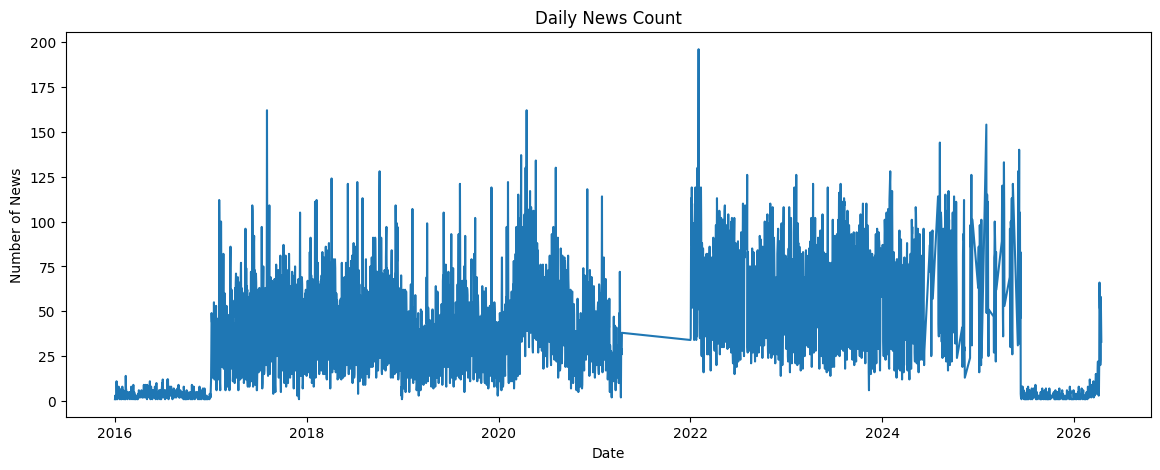

In [19]:
tmp = filtered_news_df.copy()
tmp["date"] = pd.to_datetime(tmp["date"], errors="coerce")

daily_news = tmp.groupby(tmp["date"].dt.date).size()

daily_news.plot(figsize=(14,5), title="Daily News Count")
plt.xlabel("Date")
plt.ylabel("Number of News")
plt.show()

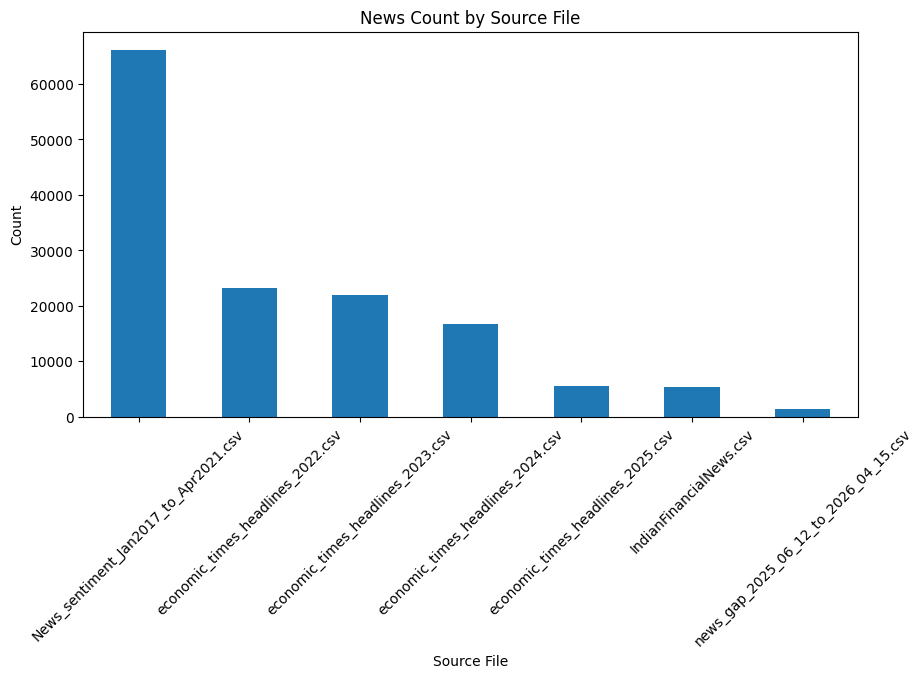

In [20]:
filtered_news_df["source_file"].value_counts().plot(kind="bar", figsize=(10,5), title="News Count by Source File")
plt.xlabel("Source File")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

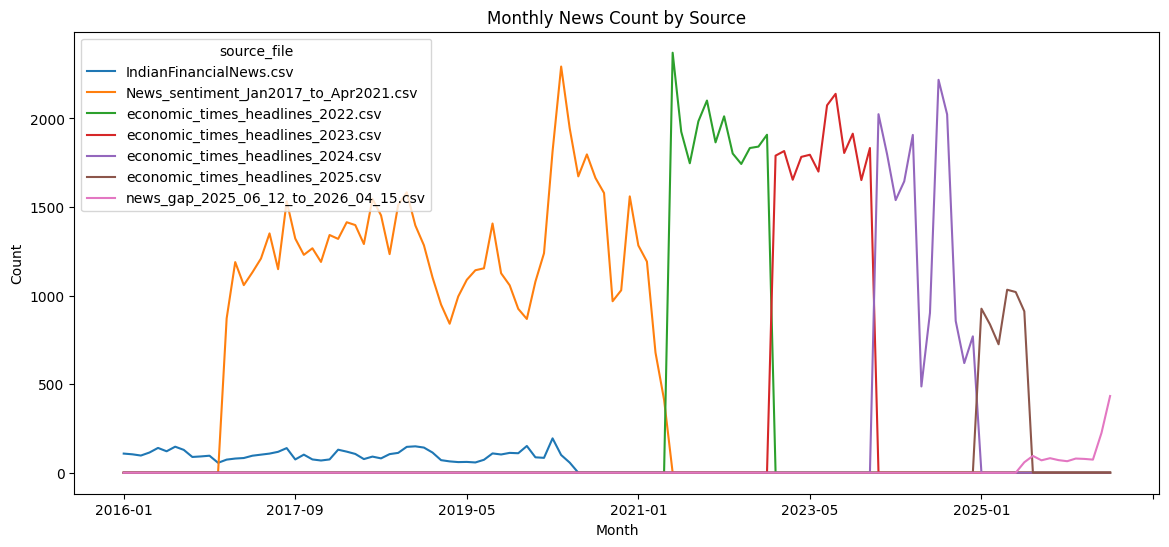

In [21]:
tmp["date"] = pd.to_datetime(tmp["date"], errors="coerce")
tmp["month"] = tmp["date"].dt.to_period("M").astype(str)

monthly_source = tmp.groupby(["month", "source_file"]).size().unstack(fill_value=0)
monthly_source.plot(figsize=(14,6), title="Monthly News Count by Source")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()


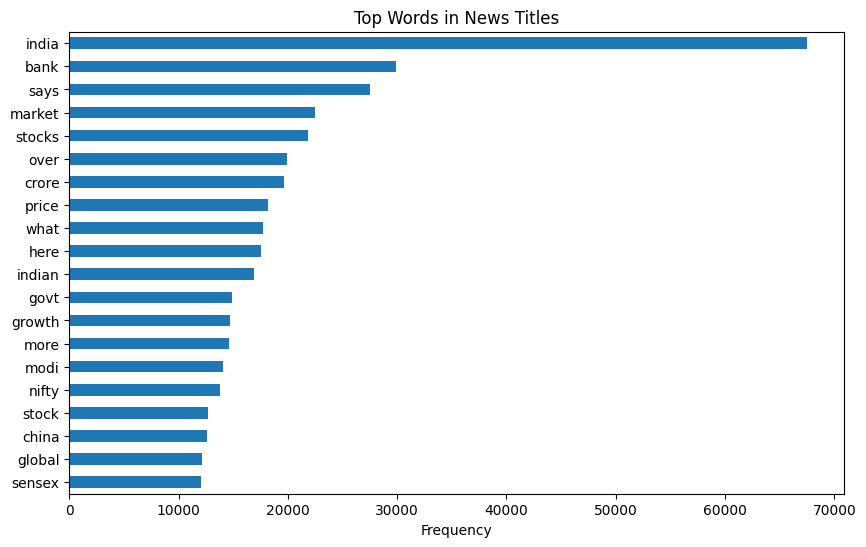

In [22]:
from collections import Counter
import re

text = " ".join(news_df["title"].dropna().astype(str)).lower()
words = re.findall(r"\b[a-zA-Z]{4,}\b", text)

stop_words = {"this","that","with","from","have","will","into","their","about","after","would","could","should","there","been"}
words = [w for w in words if w not in stop_words]

top_words = pd.Series(dict(Counter(words).most_common(20))).sort_values()
top_words.plot(kind="barh", figsize=(10,6), title="Top Words in News Titles")
plt.xlabel("Frequency")
plt.show()

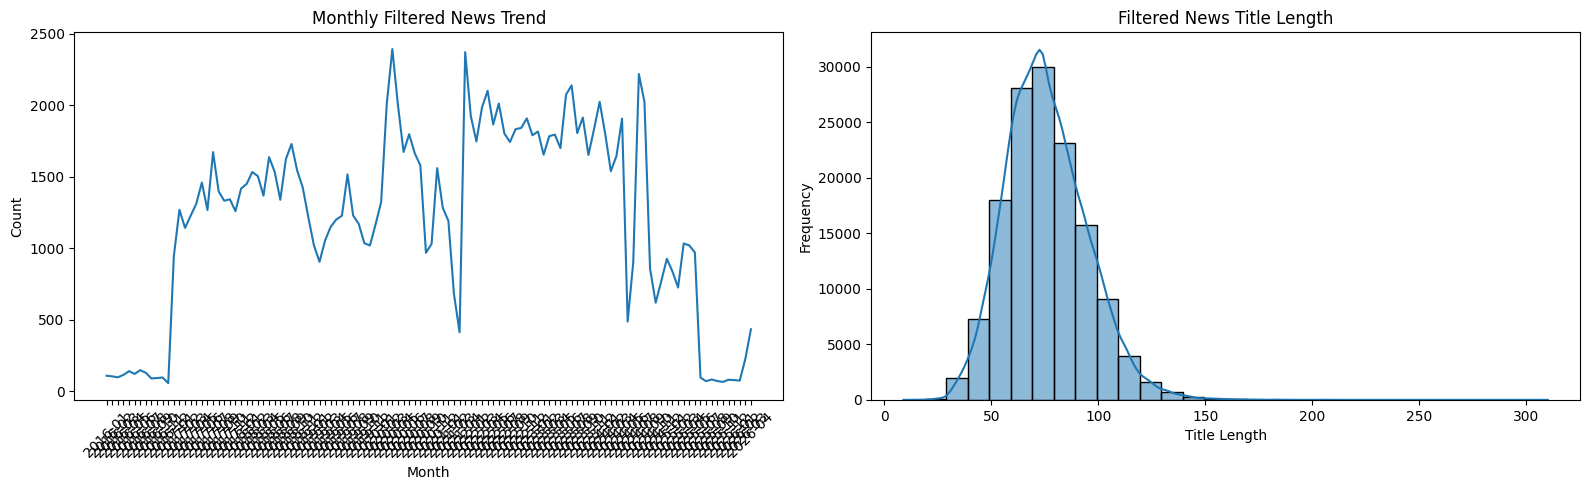

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5)) 

# 1. Monthly filtered news trend
tmp["month"] = tmp["date"].dt.to_period("M").astype(str)
monthly_counts = tmp.groupby("month").size().sort_index()
axes[0].plot(monthly_counts.index, monthly_counts.values)  
axes[0].set_title("Monthly Filtered News Trend")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# 2. Title length distribution
tmp["title_len"] = tmp["title"].fillna("").astype(str).str.len()
sns.histplot(tmp["title_len"], bins=30, ax=axes[1], kde=True)   
axes[1].set_title("Filtered News Title Length")
axes[1].set_xlabel("Title Length")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### 

In [24]:
filtered_news_df = filtered_news_df.drop(columns=[
    "description",
    "matched_keywords"
], errors="ignore")  # source_file kept this time

filtered_news_df = filtered_news_df.sort_values("date", ascending=True).reset_index(drop=True)

In [25]:
filtered_news_df

,date,title,url,source_file,categories,relevance_score,has_negation,impact_tier
0,2016-01-01,Lending to foreign step-down arms of Indian fi...,<NA>,IndianFinancialNews.csv,sector_banking_finance,2,False,LOW
1,2016-01-02,Forex reserves up $943 mn,<NA>,IndianFinancialNews.csv,macro_government,3,False,MEDIUM
2,2016-01-02,SBI: Lending rate cut unlikely till end-Mar,<NA>,IndianFinancialNews.csv,stock_specific,2,True,LOW
3,2016-01-02,IDBI Bank to raise Rs 900 cr through Basel-III...,<NA>,IndianFinancialNews.csv,sector_banking_finance,2,False,LOW
4,2016-01-03,IDBI Bank strategic stake sale unlikely this f...,<NA>,IndianFinancialNews.csv,order_wins_deals,3,False,MEDIUM
...,...,...,...,...,...,...,...,...
140147,2026-04-15,Big US banks rake in near $50bn profit as Iran...,https://www.theguardian.com/p/x4zhpv,news_gap_2025_06_12_to_2026_04_15.csv,geopolitical,3,False,MEDIUM
140148,2026-04-15,$30m an hour: big oil reaping huge war windfal...,https://www.theguardian.com/p/x4z76y,news_gap_2025_06_12_to_2026_04_15.csv,geopolitical,3,False,MEDIUM
140149,2026-04-15,"Sensex jumps 1400 points, Nifty 50 above 24,28...",https://www.livemint.com/market/stock-market-n...,news_gap_2025_06_12_to_2026_04_15.csv,macro_government,3,False,MEDIUM
140150,2026-04-15,"Sensex Rises 1400 Points, Investors Earn Rs 9 ...",https://www.news18.com/business/markets/sensex...,news_gap_2025_06_12_to_2026_04_15.csv,macro_government,3,False,MEDIUM


In [26]:
print(filtered_news_df[filtered_news_df["url"].isna()]["source_file"].value_counts())

source_file
IndianFinancialNews.csv    5355
Name: count, dtype: int64


### checking relevence score that that tell how important is this article 

In [27]:
mask = (filtered_news_df["url"].isna()) & (filtered_news_df["source_file"] == "IndianFinancialNews.csv")

print(filtered_news_df[mask]["relevance_score"].value_counts())

relevance_score
2     3326
3      745
5      648
4      418
7       82
1       73
6       41
8       17
9        3
10       2
Name: count, dtype: int64


In [28]:
!pip install googlesearch-python

### filling missing url(those are important relevence score is higher) through google search and those are low relvence score just filling it with url is not available 

In [29]:
mask = (filtered_news_df["url"].isna()) & (filtered_news_df["source_file"] == "IndianFinancialNews.csv")

# Fill low relevance ones with placeholder
low_mask = mask & (filtered_news_df["relevance_score"] <= 6)
filtered_news_df.loc[low_mask, "url"] = "URL_NOT_AVAILABLE"

# Search only for high relevance ones
high_mask = mask & (filtered_news_df["relevance_score"] >= 7)

from googlesearch import search
import time

def find_url(title):
    try:
        results = list(search(title, num_results=1))
        time.sleep(2)
        return results[0] if results else "URL_NOT_FOUND"
    except:
        return "URL_NOT_FOUND"

filtered_news_df.loc[high_mask, "url"] = filtered_news_df.loc[high_mask, "title"].apply(find_url)

In [30]:
print(filtered_news_df["url"].value_counts().get("URL_NOT_AVAILABLE", 0))

5251


In [31]:
filtered_news_df

,date,title,url,source_file,categories,relevance_score,has_negation,impact_tier
0,2016-01-01,Lending to foreign step-down arms of Indian fi...,URL_NOT_AVAILABLE,IndianFinancialNews.csv,sector_banking_finance,2,False,LOW
1,2016-01-02,Forex reserves up $943 mn,URL_NOT_AVAILABLE,IndianFinancialNews.csv,macro_government,3,False,MEDIUM
2,2016-01-02,SBI: Lending rate cut unlikely till end-Mar,URL_NOT_AVAILABLE,IndianFinancialNews.csv,stock_specific,2,True,LOW
3,2016-01-02,IDBI Bank to raise Rs 900 cr through Basel-III...,URL_NOT_AVAILABLE,IndianFinancialNews.csv,sector_banking_finance,2,False,LOW
4,2016-01-03,IDBI Bank strategic stake sale unlikely this f...,URL_NOT_AVAILABLE,IndianFinancialNews.csv,order_wins_deals,3,False,MEDIUM
...,...,...,...,...,...,...,...,...
140147,2026-04-15,Big US banks rake in near $50bn profit as Iran...,https://www.theguardian.com/p/x4zhpv,news_gap_2025_06_12_to_2026_04_15.csv,geopolitical,3,False,MEDIUM
140148,2026-04-15,$30m an hour: big oil reaping huge war windfal...,https://www.theguardian.com/p/x4z76y,news_gap_2025_06_12_to_2026_04_15.csv,geopolitical,3,False,MEDIUM
140149,2026-04-15,"Sensex jumps 1400 points, Nifty 50 above 24,28...",https://www.livemint.com/market/stock-market-n...,news_gap_2025_06_12_to_2026_04_15.csv,macro_government,3,False,MEDIUM
140150,2026-04-15,"Sensex Rises 1400 Points, Investors Earn Rs 9 ...",https://www.news18.com/business/markets/sensex...,news_gap_2025_06_12_to_2026_04_15.csv,macro_government,3,False,MEDIUM


In [32]:
import torch
import numpy as np
from transformers import BertTokenizer, BertModel

device = torch.device("cuda")
print("Using:", torch.cuda.get_device_name(0))

tokenizer = BertTokenizer.from_pretrained("ProsusAI/finbert")
model = BertModel.from_pretrained("ProsusAI/finbert").to(device)
model.eval()

def get_embedding(title):
    inputs = tokenizer(str(title), return_tensors="pt",
                      truncation=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    embedding = outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy()
    del inputs, outputs
    return embedding

embeddings = []
for i, title in enumerate(filtered_news_df["title"]):
    emb = get_embedding(title)
    embeddings.append(emb)
    if i % 1000 == 0:
        print(f"Processed {i} / {len(filtered_news_df)}")

embeddings = np.array(embeddings, dtype=np.float16)
np.save("title_embeddings.npy", embeddings)
print("Done! Shape:", embeddings.shape)

c:\Users\laves\backup\nifty-50-50\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using: NVIDIA GeForce RTX 5050 Laptop GPU


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 30162.85it/s]
BertModel LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.bias              | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Processed 0 / 140152
Processed 1000 / 140152
Processed 2000 / 140152
Processed 3000 / 140152
Processed 4000 / 140152
Processed 5000 / 140152
Processed 6000 / 140152
Processed 7000 / 140152
Processed 8000 / 140152
Processed 9000 / 140152
Processed 10000 / 140152
Processed 11000 / 140152
Processed 12000 / 140152
Processed 13000 / 140152
Processed 14000 / 140152
Processed 15000 / 140152
Processed 16000 / 140152
Processed 17000 / 140152
Processed 18000 / 140152
Processed 19000 / 140152
Processed 20000 / 140152
Processed 21000 / 140152
Processed 22000 / 140152
Processed 23000 / 140152
Processed 24000 / 140152
Processed 25000 / 140152
Processed 26000 / 140152
Processed 27000 / 140152
Processed 28000 / 140152
Processed 29000 / 140152
Processed 30000 / 140152
Processed 31000 / 140152
Processed 32000 / 140152
Processed 33000 / 140152
Processed 34000 / 140152
Processed 35000 / 140152
Processed 36000 / 140152
Processed 37000 / 140152
Processed 38000 / 140152
Processed 39000 / 140152
Processed 400

In [33]:
embeddings

array([[ 0.03604 , -0.05853 ,  0.401   , ..., -0.2212  ,  0.4294  ,
        -0.03894 ],
       [ 0.3997  , -0.757   ,  0.551   , ...,  0.9653  ,  0.6333  ,
        -0.2825  ],
       [ 0.0902  , -1.881   ,  0.4353  , ...,  0.09875 ,  0.3577  ,
         0.0676  ],
       ...,
       [ 0.3394  , -0.475   ,  0.2532  , ..., -0.1707  , -0.313   ,
        -0.162   ],
       [ 0.777   , -0.2467  ,  0.2053  , ..., -0.445   , -0.01427 ,
        -0.3445  ],
       [-0.002998,  0.3633  , -0.4292  , ...,  0.06305 ,  0.1285  ,
         0.1927  ]], shape=(140152, 768), dtype=float16)

In [34]:
print(filtered_news_df.columns.tolist())

['date', 'title', 'url', 'source_file', 'categories', 'relevance_score', 'has_negation', 'impact_tier']


In [35]:
filtered_news_df.head(3)

,date,title,url,source_file,categories,relevance_score,has_negation,impact_tier
0,2016-01-01,Lending to foreign step-down arms of Indian fi...,URL_NOT_AVAILABLE,IndianFinancialNews.csv,sector_banking_finance,2,False,LOW
1,2016-01-02,Forex reserves up $943 mn,URL_NOT_AVAILABLE,IndianFinancialNews.csv,macro_government,3,False,MEDIUM
2,2016-01-02,SBI: Lending rate cut unlikely till end-Mar,URL_NOT_AVAILABLE,IndianFinancialNews.csv,stock_specific,2,True,LOW


In [36]:
print(f"Start : {filtered_news_df['date'].min()}")
print(f"End   : {filtered_news_df['date'].max()}")


Start : 2016-01-01 00:00:00
End   : 2026-04-15 00:00:00


Using device: cuda


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 6634.15it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Computing FinBERT sentiment on titles...

Sample results:
        date                                              title  sentiment  \
0 2016-01-01  Lending to foreign step-down arms of Indian fi...   0.063487   
1 2016-01-02  IDBI Bank to raise Rs 900 cr through Basel-III...  -0.486864   
2 2016-01-02                          Forex reserves up $943 mn  -0.874433   
3 2016-01-02        SBI: Lending rate cut unlikely till end-Mar   0.134054   
4 2016-01-03  ASK Group to invest Rs 1,500 cr in real estate...   0.818276   
5 2016-01-03  IDBI Bank strategic stake sale unlikely this f...   0.842500   
6 2016-01-04  RBI imposes Rs 1 cr fine on State Bank of Trav...   0.075603   
7 2016-01-04  IDBI Bank raises Rs 1,900 cr via Basel-III com...  -0.521736   
8 2016-01-04  Indian Bank hikes interest rates for NRI deposits   0.239040   
9 2016-01-05  RBI to auction new 10-year benchmark bond on F...   0.794694   

  impact_tier  
0         LOW  
1         LOW  
2      MEDIUM  
3         LOW  
4  

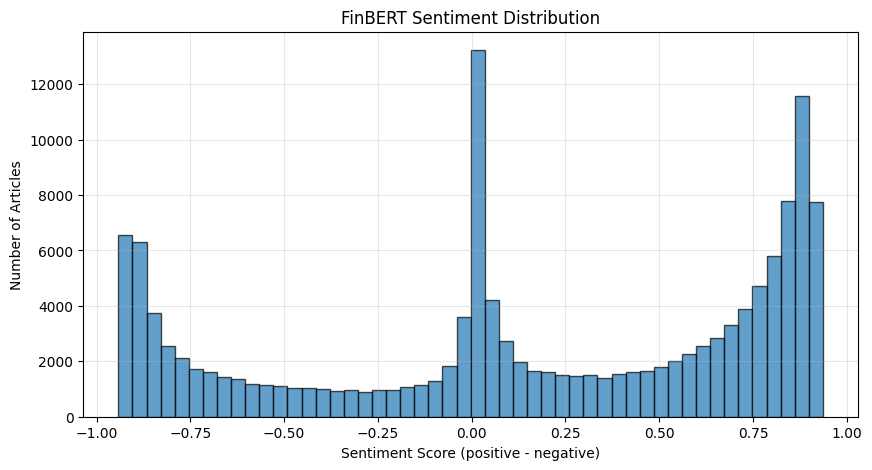


Saved with FinBERT sentiment to: c:\Users\laves\backup\nifty-50-50\notebooks\filtered_news_with_finbert.csv


In [37]:
# ============================================================
# FinBERT Sentiment Analysis (GPU)
# ============================================================
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load FinBERT model and tokenizer
model_name = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)
model.to(device)
model.eval()

# Function to get sentiment scores for a batch of texts
def get_sentiment_batch(texts, batch_size=64):
    """
    Returns a list of sentiment scores (positive - negative) for each text.
    """
    scores = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        # Tokenize
        inputs = tokenizer(batch, return_tensors="pt", truncation=True, max_length=512, padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1).cpu().numpy()
        # probs: [negative, neutral, positive] -> score = positive - negative
        batch_scores = probs[:, 2] - probs[:, 0]
        scores.extend(batch_scores.tolist())
    return scores

# Apply to your filtered news DataFrame
print("Computing FinBERT sentiment on titles...")
titles = filtered_news_final["title"].astype(str).tolist()
sentiment_scores = get_sentiment_batch(titles, batch_size=128)  # adjust batch size based on GPU memory

filtered_news_final["sentiment"] = sentiment_scores

# ============================================================
# Inspect results
# ============================================================
print("\nSample results:")
print(filtered_news_final[["date", "title", "sentiment", "impact_tier"]].head(10))

# Distribution plot
plt.figure(figsize=(10,5))
plt.hist(filtered_news_final["sentiment"], bins=50, edgecolor='black', alpha=0.7)
plt.title("FinBERT Sentiment Distribution")
plt.xlabel("Sentiment Score (positive - negative)")
plt.ylabel("Number of Articles")
plt.grid(True, alpha=0.3)
plt.show()

# ============================================================
# Save with sentiment (optional)
# ============================================================
output_path = ROOT / "notebooks" / "filtered_news_with_finbert.csv"
filtered_news_final.to_csv(output_path, index=False)
print(f"\nSaved with FinBERT sentiment to: {output_path}")

In [43]:
# ---------- Further refinement for database merging ----------
# 1. Minimum relevance
MIN_SCORE = 3
filtered_news_final = filtered_news_final[filtered_news_final['relevance_score'] >= MIN_SCORE]

# 2. Keep only HIGH and MEDIUM impact
filtered_news_final = filtered_news_final[filtered_news_final['impact_tier'].isin(['HIGH', 'MEDIUM'])]

# 3. Discard negation articles (optional)
filtered_news_final = filtered_news_final[~filtered_news_final['has_negation']]

# 4. Filter to relevant categories
target_cats = ['earnings_results', 'order_wins_deals', 'rating_regulatory',
               'management_corporate', 'macro_government', 'geopolitical']
mask = filtered_news_final['categories'].apply(lambda x: any(c in x for c in target_cats))
filtered_news_final = filtered_news_final[mask]

# 5. Ensure date range matches market data
filtered_news_final = filtered_news_final[
    (filtered_news_final['date'] >= '2016-01-01') &
    (filtered_news_final['date'] <= '2026-04-15')
]

print(f"Final refined news size: {len(filtered_news_final)} rows")
# ---------- End of additional filters ----------

Final refined news size: 76799 rows


In [47]:
import os
import pandas as pd
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from dotenv import load_dotenv

# 1. Load credentials from your .env file
load_dotenv('../.env')

user = os.getenv('DB_USER')
password = os.getenv('DB_PASSWORD')
host = os.getenv('DB_HOST')
db_name = os.getenv('DB_NAME')
port = os.getenv('DB_PORT', 5432)

# 2. Create an independent connection engine
connection_url = URL.create(
    drivername="postgresql",
    username=user,
    password=password,
    host=host,
    port=port,
    database=db_name,
)
engine = create_engine(connection_url)

# 3. Grab the columns that match your refined_news SQL table
db_columns = [
    'date', 'title', 'url', 'source_file', 
    'categories', 'relevance_score', 'has_negation', 'impact_tier'
]

# Use the FINAL dataframe
df_to_load = filtered_news_final[db_columns].copy()

print(f"Loading {len(df_to_load)} rows into the 'refined_news' table...")

# 4. Push directly to the PostgreSQL database
try:
    df_to_load.to_sql(
        'refined_news', 
        con=engine, 
        if_exists='append', 
        index=False,
        method='multi',
        chunksize=10000
    )
    print("✅ Successfully loaded data from filtered_news_final!")
except Exception as e:
    print(f"❌ Error loading data: {e}")


Loading 76799 rows into the 'refined_news' table...
✅ Successfully loaded data from filtered_news_final!


In [48]:
import torch
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModel
from sklearn.decomposition import PCA

# 1. Setup the Embedding Model (Using FinBERT)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_name = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)
model.eval()

# 2. Function to generate embeddings in batches (so we don't crash the GPU)
def get_compressed_embeddings(texts, target_dim=8, batch_size=128):
    print("Generating raw 768-dimension embeddings...")
    all_embeddings = []
    
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        
        # Tokenize the text
        inputs = tokenizer(batch, return_tensors="pt", truncation=True, max_length=128, padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        with torch.no_grad():
            outputs = model(**inputs)
            
        # Get the embedding for the [CLS] token (represents the whole sentence)
        batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.extend(batch_embeddings)
        
        if i % (batch_size * 10) == 0:
            print(f"Processed {i} / {len(texts)} articles...")
            
    all_embeddings = np.array(all_embeddings)
    
    # 3. Compress the embeddings from 768 down to 8 dimensions using PCA
    print(f"Compressing embeddings from {all_embeddings.shape[1]} down to {target_dim} dimensions...")
    pca = PCA(n_components=target_dim)
    compressed = pca.fit_transform(all_embeddings)
    
    print(f"Compression complete! New shape: {compressed.shape}")
    return compressed

# 4. Run the function on your filtered news titles
titles = filtered_news_final["title"].astype(str).tolist()

# Get the 8-dimension compressed embeddings
compressed_vectors = get_compressed_embeddings(titles, target_dim=8)

# 5. Add these 8 new dimensions directly to your DataFrame
for i in range(8):
    filtered_news_final[f"embed_dim_{i+1}"] = compressed_vectors[:, i]

print("✅ Added 8 highly-dense embedding columns to filtered_news_final!")
display(filtered_news_final.head(3))


Using device: cuda


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 23131.85it/s]
BertModel LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.bias              | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating raw 768-dimension embeddings...
Processed 0 / 76799 articles...
Processed 1280 / 76799 articles...
Processed 2560 / 76799 articles...
Processed 3840 / 76799 articles...
Processed 5120 / 76799 articles...
Processed 6400 / 76799 articles...
Processed 7680 / 76799 articles...
Processed 8960 / 76799 articles...
Processed 10240 / 76799 articles...
Processed 11520 / 76799 articles...
Processed 12800 / 76799 articles...
Processed 14080 / 76799 articles...
Processed 15360 / 76799 articles...
Processed 16640 / 76799 articles...
Processed 17920 / 76799 articles...
Processed 19200 / 76799 articles...
Processed 20480 / 76799 articles...
Processed 21760 / 76799 articles...
Processed 23040 / 76799 articles...
Processed 24320 / 76799 articles...
Processed 25600 / 76799 articles...
Processed 26880 / 76799 articles...
Processed 28160 / 76799 articles...
Processed 29440 / 76799 articles...
Processed 30720 / 76799 articles...
Processed 32000 / 76799 articles...
Processed 33280 / 76799 articles

,date,title,description,url,source_file,categories,matched_keywords,relevance_score,has_negation,impact_tier,sentiment,embed_dim_1,embed_dim_2,embed_dim_3,embed_dim_4,embed_dim_5,embed_dim_6,embed_dim_7,embed_dim_8
2,2016-01-02,Forex reserves up $943 mn,India's foreign exchange reserves rose $943 mi...,URL_NOT_AVAILABLE,IndianFinancialNews.csv,macro_government,forex reserve,3,False,MEDIUM,-0.874433,-1.399180,-10.422005,-0.853452,-2.37682,-2.588253,1.288928,0.784048,-0.762507
5,2016-01-03,IDBI Bank strategic stake sale unlikely this f...,Government is unlikely to go for a strategic s...,URL_NOT_AVAILABLE,IndianFinancialNews.csv,order_wins_deals,stake sale,3,False,MEDIUM,0.842500,10.835131,3.227509,-0.090591,0.46225,-2.584018,-0.380591,1.035399,-0.354629
8,2016-01-04,Indian Bank hikes interest rates for NRI deposits,The interest rate for Foreign Currency Non-Res...,URL_NOT_AVAILABLE,IndianFinancialNews.csv,macro_government|sector_banking_finance,dollar|interest rate,5,False,MEDIUM,0.239040,-3.750870,1.126733,-0.326069,-2.53738,-0.378449,-7.744554,-1.407648,-1.166799
